In [2]:
import tmm

from numpy import pi, linspace, inf, array
import numpy as np
import math
from scipy.interpolate import interp1d
from scipy.integrate import quad
from scipy.signal import hilbert
import matplotlib.pyplot as plt
%matplotlib inline

degree = pi/180

In [3]:
# generate nk for spatial KK stack
def eps(x, a, gam, nb):
    return nb**2 - a * gam / (x + 1j*gam)

In [4]:
def generate_n_and_d(gam, a, nb):
    xq = linspace(-200*gam, 200*gam, 100000)
    func = np.zeros_like(xq)

    for i, x in enumerate (xq):
        func[i] = np.imag(eps(x, a, gam, nb))

    eq = interp1d(xq,func,kind='nearest')
    Hx = hilbert(eq(xq))
    
    xq2 = np.concatenate((linspace(0,10*gam,15), linspace(10*gam,50*gam,10) , linspace(50*gam,200*gam,5)))
    xq2 = np.unique(np.concatenate((-xq2 , xq2)))
   # midpoints = (xq[:-1] + xq[1:]) / 2
   # eq = interp1d(xq,eps(xq,a,gam,nb),kind='nearest')
    d_list = np.diff(xq2)
    eq2 = interp1d(xq,Hx,kind='nearest')

    n_list = np.sqrt(-np.imag(eq2(xq2[:-1])) + nb**2 + 1j*np.real(eq2(xq2[:-1])))
    #n_list_full = np.sqrt(eq(xq))
   # n_list_full = np.append(n_list, n_list[-1])
   # xq2 = np.linspace(-200*gam, 200*gam, num=100000)
   # eq2 = interp1d(xq,n_list_full,kind='nearest')

   # eq3 = interp1d(xq2, eps(xq2,a,gam,nb),kind='nearest')
   # n_list_trapz = eq2(xq2)
   # print(n_list)
   # print(d_list)
   # n_list_mid = np.sqrt(eq(midpoints))
    #print(n_list_mid)

    # delete when done debugging
    #n_list[-1] = nb
    #n_list[0] = nb
    #d_list[-1] = inf
    #d_list[0] = inf

    '''
    # plot dielectric function and refractive index

    plt.figure(1)
    plt.plot(xq, np.imag(eq(xq)), label='imag')
    plt.plot(xq, np.real(eq(xq)), label='real')
    plt.xlabel('x ($\mu$m)')
    plt.ylabel('Dielectric Function')
    plt.title('Spatial KK Dielectric Function of Thin Film Stack');
    plt.legend(loc='upper right')

    plt.figure(3)
    plt.plot(xq2, np.imag(n_list_trapz), label='trapz')
   # plt.plot(xq2, np.real(n_list_trapz), label='real')
    plt.plot(xq2, np.imag(np.sqrt(eq3(xq2))), label='cont.')
   # plt.plot(xq2, np.real(np.sqrt(eq3(xq2))), label='real')
    plt.scatter(xq, np.imag(n_list_full), label='disc.')
   # plt.scatter(xq, np.real(n_list_full), label='real')
    plt.xlabel('x ($\mu$m)')
    plt.ylabel('Dielectric Function')
    plt.title('Spatial KK Dielectric Function of Thin Film Stack');
    plt.legend(loc='upper right')
    plt.xlim([0, 0.2])
    plt.ylim([0,0.02])

    plt.figure(2)
    #plt.plot(xq, np.real(nkq(xq)), label='n')
    #plt.plot(xq, np.imag(nkq(xq)), label='k')
    plt.plot(xq, np.real(n_list_full), label='n_left')
    plt.plot(xq, np.imag(n_list_full), label='k_left')
    plt.plot(midpoints, np.real(n_list_mid+0.25), label='n_mid')
    plt.plot(midpoints, np.imag(n_list_mid)+0.25, label='k_mid')
    plt.xlabel('x ($\mu$m)')
    plt.ylabel('Refractive Index')
    plt.title('Spatial KK Refractive Index of Thin Film Stack');
    plt.legend(loc='upper right')
    plt.xlim([-0.1, 0.1])
    '''

    return (n_list.tolist(), d_list.tolist())

In [5]:
def generate_x_from_d(d_list):
    x_list = np.zeros(len(d_list)+1)
    curr = 0
    for i, thickness in enumerate(d_list):
        x_list[i+1] = curr + thickness
        curr = x_list[i+1]
    return x_list

In [34]:
def generate_StackofStacks(gam, a, nb, num_stacks, t_prop):
    n_list = []
    d_list = []
    c_list = []
    c_list_KK = []

    n_list_KK, d_list_KK = generate_n_and_d(gam, a, nb)
    t_KK = np.sum(d_list_KK)
    t_inc = t_prop*t_KK
    print(f"t_inc is: {t_inc}")
    t_total = num_stacks*(t_inc + t_KK)
    print(f"t_total is: {t_total}")
    #print(f'length of KK MS is: {t_KK}')

    x_list = generate_x_from_d(d_list_KK[1:-1])
   # k_bulk = np.trapz(np.imag(n_list_KK[:-1]), x=x_list) / t_KK

    # this k_bulk is giving a value that makes FOM_LR < FOM_bulk (which should never happen.
    # figure it out with keith later and use trapz for now)
    k_bulk = np.sum(d_list_KK * np.imag(n_list_KK)) / t_KK
    print(f'k_bulk from trapz is: {k_bulk}')
    losses_total = t_total * k_bulk
    print(f'total losses are: {losses_total}')

    plt.plot(x_list, np.imag(n_list_KK[:-1]))
    plt.step(x_list, np.imag(n_list_KK[:-1]), where='mid')
    plt.xlim([1.5, 1.8])

    for i in range(len(d_list_KK)):
        c_list_KK.append('c')

    for i in range(num_stacks):
        n_list.extend(n_list_KK)
        d_list.extend(d_list_KK)
        c_list.extend(c_list_KK)
        n_list.append(nb + 1j*k_bulk)
        d_list.append(t_inc)
        c_list.append('i')

    # uncomment this if you want to append instead of change endpoints
    
    d_list.append(inf)
    d_list.insert(0, inf)
    n_list.append(nb+0j)
    n_list.insert(0, nb+0j)
    c_list.insert(0, 'i')
    c_list.append('i')
    

    # uncomment this if you want the opposite of above
    '''
    d_list[-1] = inf
    d_list[0] = inf
    n_list[-1] = nb+0j
    n_list[0] = nb+0j
    c_list[-1] = 'i'
    c_list[0] = 'i'
    '''

    return (n_list, d_list, c_list, losses_total)



In [7]:
A = 0.1
gam = 0.01
nb = 1.7
x_list, d_list, n_list, n_list_full = generate_n_and_d(gam, A, nb)
#x_list = generate_x_from_d(d_list[1:-1])
#print(x_list)
t_KK = np.sum(d_list)
print(f'length of KK MS is: {t_KK}')
losses_trapz = np.trapz(np.imag(n_list_full), x=x_list)
print(f'k_bulk from trapz is: {losses_trapz/t_KK}')
losses_sum = np.sum(d_list * np.imag(n_list))
#for i, d in enumerate(d_list):
#    print(f'At element {i}, d is: {d}, and k is: {np.imag(n_list[i])}')

k_bulk = losses_sum/t_KK
print(f'k_bulk from sum is: {k_bulk}')

ValueError: not enough values to unpack (expected 4, got 2)

t_inc is: 4.0
t_total is: 8.0
k_bulk from trapz is: 0.00023101172163301722
total losses are: 0.0018480937730641377


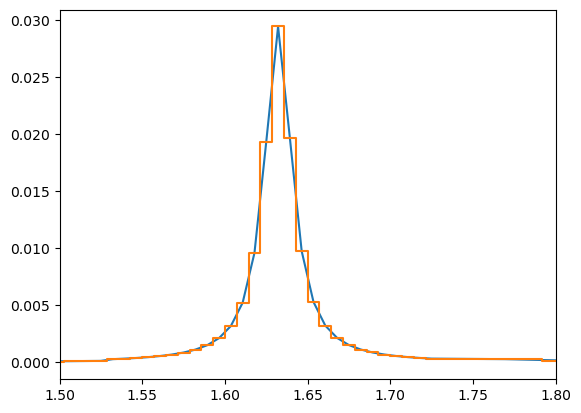

In [35]:
num_stacks = 1
t_prop = 1
n_list, d_list, c_list, losses_total = generate_StackofStacks(gam, A, nb, num_stacks, t_prop)

In [8]:
# wavelength dependence calculation of RTA using incoherent TMM function (inc_tmm)

def TRA_func(n_list, d_list, c_list):
    pol = 'p'
    lambda_list = np.linspace(2,5,100)
    angle = 0
    T_list = np.zeros_like(lambda_list)
    R_list = np.zeros_like(lambda_list)
    A_list = np.zeros_like(lambda_list)
    
    for j, lamb in enumerate(lambda_list):
        T_list[j] = tmm.inc_tmm(pol, n_list, d_list, c_list, angle, lamb)['T']
        R_list[j] = tmm.inc_tmm(pol, n_list, d_list, c_list, angle, lamb)['R']
      #  T_list[j] = tmm.coh_tmm(pol, n_list, d_list, angle, lamb)['T']
      #  R_list[j] = tmm.coh_tmm(pol, n_list, d_list, angle, lamb)['R']
        A_list[j] = 1 - T_list[j] - R_list[j]

    return (T_list, R_list, A_list)
    

t_inc is: 0.0
t_total is: 4.0
k_bulk from trapz is: 0.00023101172163301722
total losses are: 0.0009240468865320689
[(1.7+0j), (1.7000000037252856+7.352757341427891e-07j), (1.7000702518317357+1.1137352455946388e-06j), (1.7001545078230564+1.8820840071876437e-06j), (1.7002815469822594+3.840497640548422e-06j), (1.7005574539410524+1.1756852001021376e-05j), (1.7006175022940397+1.4160950736798689e-05j), (1.700689900229496+1.7385386067875613e-05j), (1.700779132184954+2.185060254469796e-05j), (1.7008921454715673+2.8285344595130057e-05j), (1.7010403083677201+3.804366119617175e-05j), (1.7012435853323935+5.387900166753006e-05j), (1.7015405289278565+8.211826169178254e-05j), (1.70201633960291+0.00014009618287900535j), (1.7029041099534825+0.0002908183805325118j), (1.7031225454459542+0.00033655082780365453j), (1.7033773315219092+0.0003942898712706368j), (1.7036745741637662+0.0004677069159901817j), (1.7040299282941505+0.0005641735803916221j), (1.704456504134404+0.0006927467371861593j), (1.7049837732354

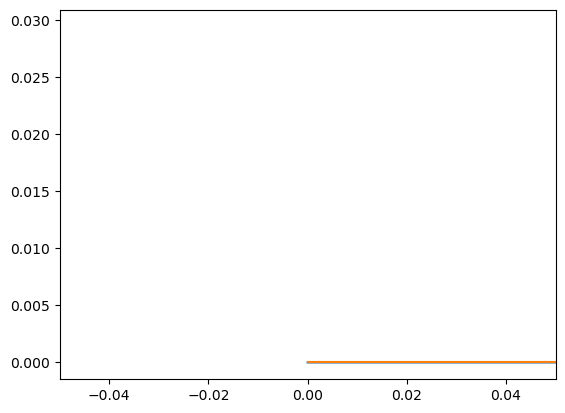

In [28]:
A = 0.1
gam = 0.01
nb = 1.7
num_stacks = 1
t_prop = 0
n_list, d_list, c_list, losses_total = generate_StackofStacks(gam, A, nb, num_stacks, t_prop)
print(n_list)
print(d_list)
print(c_list)
#d_list, n_list= generate_n_and_d(gam, A, nb)
n_list_reversed = n_list[::-1]
d_list_reversed = d_list[::-1]
c_list_reversed = c_list[::-1]

T_list_LR, R_list_LR, A_list_LR = TRA_func(n_list, d_list, c_list)
T_list_RL, R_list_RL, A_list_RL = TRA_func(n_list_reversed, d_list_reversed, c_list_reversed)
lambda_list = np.linspace(2,5,100)
#t_KK = np.sum(d_list[1:-1])
#k_bulk = np.sum(d_list[1:-1]*np.imag(n_list[1:-1])) / t_KK
#print(f'k_bulk from sum is: {k_bulk}')
#losses_total = t_KK * k_bulk

trans_bulk = np.exp(-4*np.pi*losses_total/lambda_list)
emiss_bulk = 1 - trans_bulk

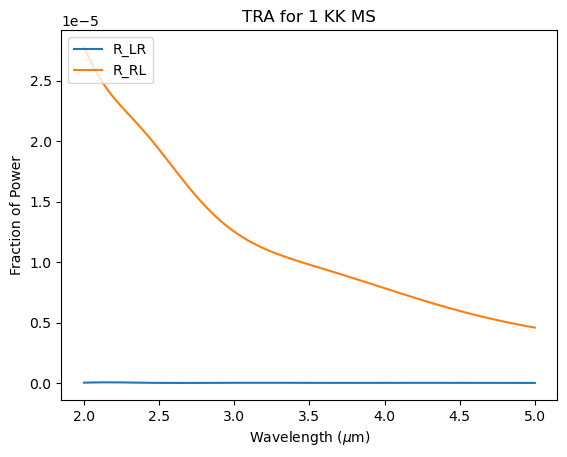

In [36]:
# plotting RTA forwards and backwards

plt.figure()
#plt.plot(lambda_list,T_list_LR, label='T_LR')
#print(T_list_LR/trans_bulk)
#plt.plot(lambda_list,T_list_RL, label='T_RL')
plt.plot(lambda_list,R_list_LR, label='R_LR')
#plt.plot(lambda_list,A_list_LR, label='A_LR')
plt.plot(lambda_list,R_list_RL, label='R_RL')
#plt.plot(lambda_list,A_list_RL, label='A_RL')
#plt.plot(lambda_list,trans_bulk, '--', label='T_bulk')
#plt.plot(lambda_list,emiss_bulk, '--', label='A_bulk')
plt.xlabel('Wavelength ($\mu$m)')
plt.ylabel('Fraction of Power')
plt.title(f'TRA for {num_stacks} KK MS');
plt.legend(loc='upper left')

In [29]:
delta_lamb = lambda_list[-1] - lambda_list[0]
FOM_LR = (np.trapz(T_list_LR, x=lambda_list))**2 / np.trapz(A_list_LR, x=lambda_list) / delta_lamb
FOM_RL = (np.trapz(T_list_RL, x=lambda_list))**2 / np.trapz(A_list_RL, x=lambda_list) / delta_lamb
FOM_bulk = (np.trapz(trans_bulk, x=lambda_list))**2 / np.trapz(emiss_bulk, x=lambda_list) / delta_lamb

print(f'FOM_LR is: {FOM_LR}')
print(f'FOM_RL is: {FOM_RL}')
print(f'FOM_bulk is: {FOM_bulk}')

FOM_LR is: 280.4727163904365
FOM_RL is: 281.4052538069956
FOM_bulk is: 280.4926619872278


In [15]:
A = 0.1
gam = 0.01
nb = 1.7
t_prop = 5
FOM_LR = np.zeros(100)
FOM_RL = np.zeros(100)
FOM_bulk = np.zeros(100)
for i in range(1, 101):
    print(i)
    n_list, d_list, c_list, losses_total = generate_StackofStacks(gam, A, nb, i, t_prop)
    n_list_reversed = n_list[::-1]
    d_list_reversed = d_list[::-1]
    c_list_reversed = c_list[::-1]

    T_list_LR, R_list_LR, A_list_LR = TRA_func(n_list, d_list, c_list)
    T_list_RL, R_list_RL, A_list_RL = TRA_func(n_list_reversed, d_list_reversed, c_list_reversed)
    lambda_list = np.linspace(2,5,100)
    delta_lamb = lambda_list[-1] - lambda_list[0]
    trans_bulk = np.exp(-4*np.pi*losses_total/lambda_list)
    emiss_bulk = 1 - trans_bulk

    FOM_LR[i-1] = (np.trapz(T_list_LR, x=lambda_list))**2 / np.trapz(A_list_LR, x=lambda_list) / delta_lamb
    FOM_RL[i-1] = (np.trapz(T_list_RL, x=lambda_list))**2 / np.trapz(A_list_RL, x=lambda_list) / delta_lamb
    FOM_bulk[i-1] = (np.trapz(trans_bulk, x=lambda_list))**2 / np.trapz(emiss_bulk, x=lambda_list) / delta_lamb

1
t_inc is: 20.0
t_total is: 24.0
k_bulk from trapz is: 0.00023213324559815017
total losses are: 0.005571197894355604
2
t_inc is: 20.0
t_total is: 48.0
k_bulk from trapz is: 0.00023213324559815017
total losses are: 0.011142395788711209
3
t_inc is: 20.0
t_total is: 72.0
k_bulk from trapz is: 0.00023213324559815017
total losses are: 0.016713593683066814
4
t_inc is: 20.0
t_total is: 96.0
k_bulk from trapz is: 0.00023213324559815017
total losses are: 0.022284791577422417
5
t_inc is: 20.0
t_total is: 120.0
k_bulk from trapz is: 0.00023213324559815017
total losses are: 0.02785598947177802
6
t_inc is: 20.0
t_total is: 144.0
k_bulk from trapz is: 0.00023213324559815017
total losses are: 0.03342718736613363
7
t_inc is: 20.0
t_total is: 168.0
k_bulk from trapz is: 0.00023213324559815017
total losses are: 0.03899838526048923
8
t_inc is: 20.0
t_total is: 192.0
k_bulk from trapz is: 0.00023213324559815017
total losses are: 0.044569583154844834
9
t_inc is: 20.0
t_total is: 216.0
k_bulk from trapz is

KeyboardInterrupt: 

Text(0, 0.5, 'FOM Enhancement')

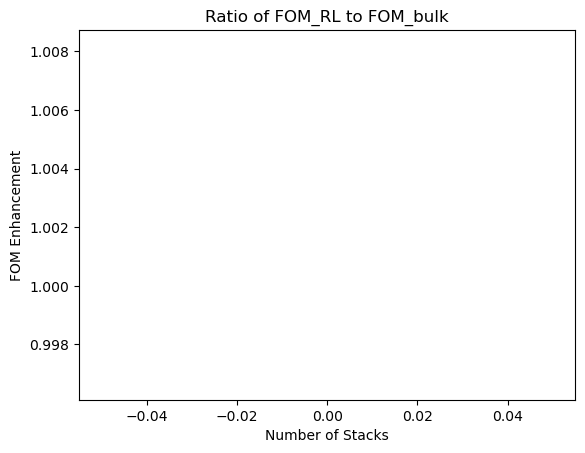

In [19]:
plt.plot(FOM_RL/FOM_bulk)
plt.plot(FOM_LR/FOM_bulk)
plt.plot(FOM_LR/FOM_RL)
plt.title('Ratio of FOM_RL to FOM_bulk')
plt.xlabel('Number of Stacks')
plt.ylabel('FOM Enhancement')

In [ ]:
arr = np.array([1, 3, 5, 7, 9])

midpoints = (arr[:-1] + arr[1:]) / 2

print(arr[:-1]) 